## Reading the Data

In [31]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../../Mod03 Correlation/Code Examples/spotify.csv")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


### Generate the Linear regression model
- x = `in_spotify_playlist`
- y = `streams`

In [32]:
x = df['in_spotify_playlists']
y = df['streams']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

predictions = model.predict(x) # use it later for visualization
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     1575.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          6.74e-204
Time:                        14:54:05   Log-Likelihood:                -20073.
No. Observations:                 952   AIC:                         4.015e+04
Df Residuals:                     950   BIC:                         4.016e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2.193e+08 

### Let's visualize this stuff

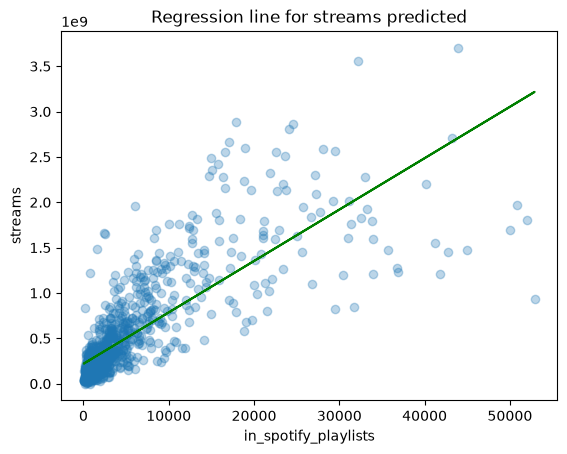

In [37]:
plt.scatter(x['in_spotify_playlists'], y, alpha=0.3)
plt.plot(x['in_spotify_playlists'], predictions, color='green')
plt.xlabel('in_spotify_playlists')
plt.ylabel('streams')
plt.title('Regression line for streams predicted')
plt.show()

###  Multiple regression
- X = `in_spotify_playlists`, `in_spotify_charts`, `in_apple_charts`
- y = `streams`

Trying to see if having more predictors/constants help us improve our prediction for streams

In [39]:
x = df[['in_spotify_playlists', 'in_spotify_charts', 'in_apple_charts']]
y = df['streams']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     563.8
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          3.30e-210
Time:                        15:08:00   Log-Likelihood:                -20051.
No. Observations:                 952   AIC:                         4.011e+04
Df Residuals:                     948   BIC:                         4.013e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.624e+08 

### Multiple regression can't be shown as one 2D line (it would be 4D)

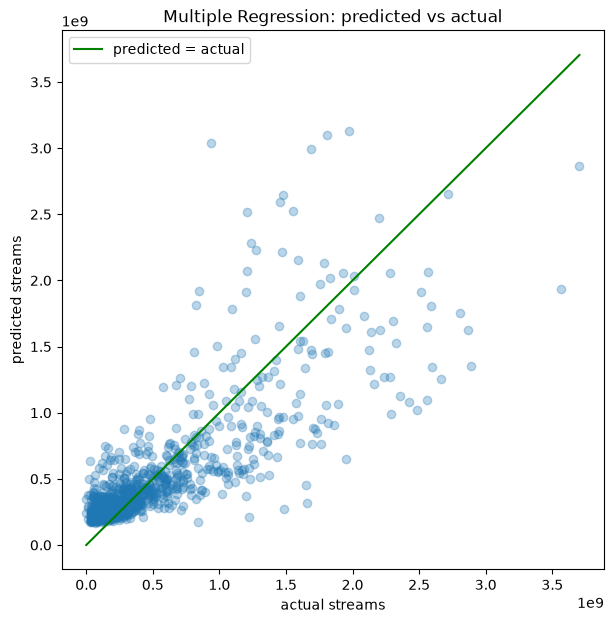

In [43]:
plt.figure(figsize=(7,7))
plt.scatter(y, predictions, alpha=0.3)

# add a 45 degree "perfect prediction" reference line

lo = min(y.min(), predictions.min())
hi = max(y.max(), predictions.max())
plt.plot([lo, hi], [lo, hi], color='green', label='predicted = actual')

plt.title("Multiple Regression: predicted vs actual")
plt.xlabel("actual streams")
plt.ylabel("predicted streams")
plt.legend()
plt.show()